<a href="https://colab.research.google.com/github/ahydeishere/Aaron-Hyde-s-Portfolio/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lets_plot
import pandas as pd
import numpy as np
from lets_plot import *
import sqlite3
import polars as pl
import geopandas as gpd
from shapely.geometry import Point

import matplotlib.pyplot as plt
from types import GeneratorType
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from xgboost import XGBRegressor
from xgboost import plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.neighbors import BallTree

LetsPlot.setup_html(isolated_frame=True)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.5 MB/s eta 0:00:00


In [2]:
nfl_data =pd.read_csv("nfl_team_season_2000_2025.csv")

In [3]:
y = nfl_data["wins"]

x = nfl_data.drop(columns=["winning_season", "team", "season", "fg_pct", "turnover_margin", "wins", "losses", "ties", "win_pct"])



In [9]:
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    random_state=987,
    test_size=.2)

# Define the XGBRegressor model
xgb = XGBRegressor(
    random_state=987)

# Define a parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Set up GridSearchCV
# Using 'neg_root_mean_squared_error' as scoring for regression (GridSearchCV maximizes scores)
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                           scoring='neg_root_mean_squared_error', cv=5, verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best estimator
model = grid_search.best_estimator_

print("Best parameters found: ", grid_search.best_params_)

# Make predictions with the best model
preds = model.predict(X_test)

# Evaluate the best model
print(f"Root Mean Squared Error (RMSE): {root_mean_squared_error(y_test, preds)}")
print(f"R-squared (R2): {r2_score(y_test, preds)}")

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters found:  {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.6}
Root Mean Squared Error (RMSE): 1.8866934776306152
R-squared (R2): 0.6511385440826416


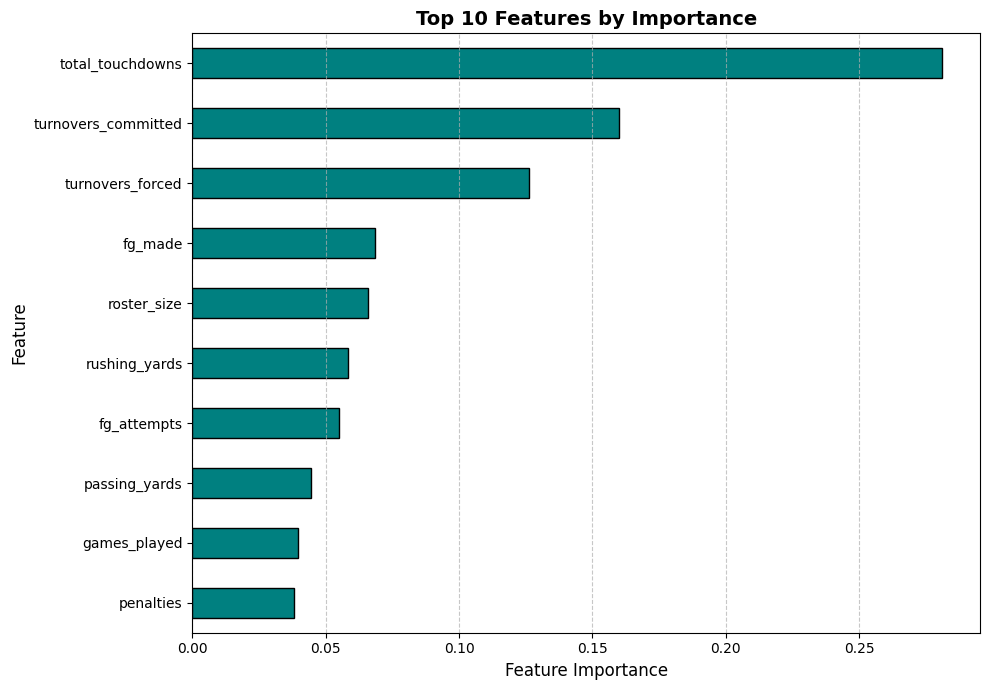

In [10]:
# Plot feature importances (top 10)
importances = model.feature_importances_
feature_names = X_train.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
top_n = 10

plt.figure(figsize=(10, 7)) # Slightly larger figure for better readability
# Get the top N features, and sort them in ascending order for correct barh plotting (largest at top)
top_features_plot = feat_imp.head(top_n).sort_values(ascending=True)

top_features_plot.plot(kind='barh', color='teal', edgecolor='black') # Use a distinct color and add edge for definition

plt.xlabel('Feature Importance', fontsize=12) # Larger font for x-label
plt.ylabel('Feature', fontsize=12) # Add y-label for clarity
plt.title(f'Top {top_n} Features by Importance', fontsize=14, weight='bold') # Bolder and larger title
plt.xticks(fontsize=10) # Adjust tick font sizes
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7) # Add a horizontal grid for easier comparison

plt.tight_layout()
plt.show()

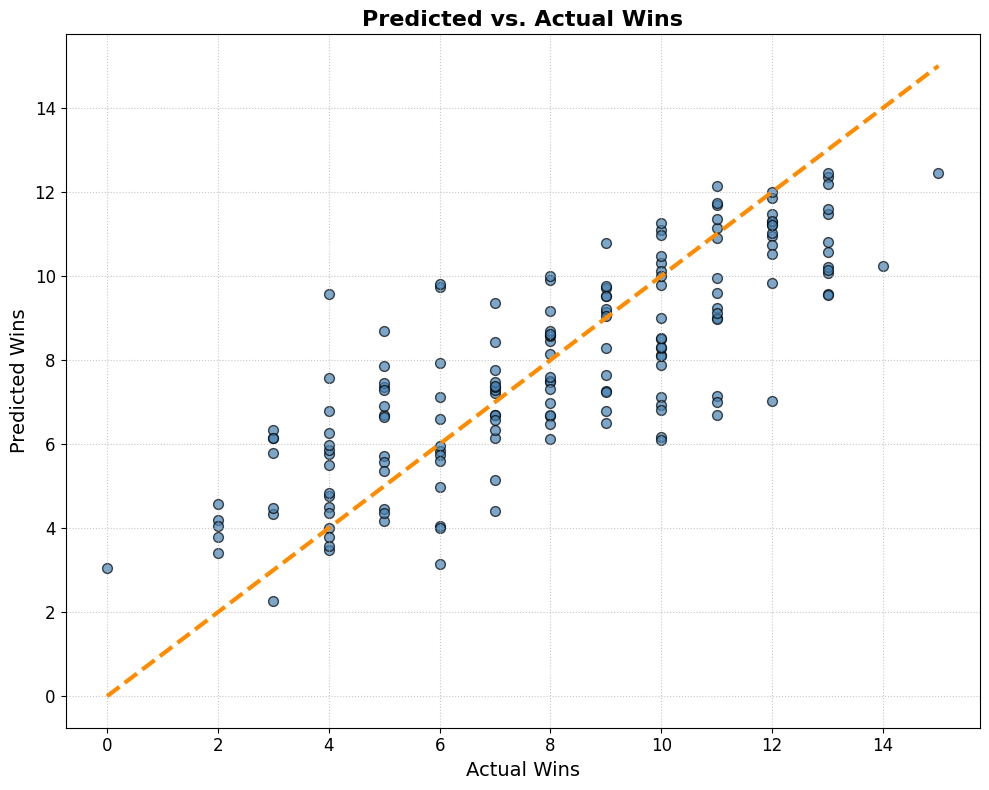

In [11]:
plt.figure(figsize=(10, 8)) # Increase figure size
plt.scatter(y_test, preds, alpha=0.7, color='steelblue', edgecolor='k', s=50) # Adjust color, alpha, edge, and size
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'darkorange', linestyle='--', lw=3) # Change line color, style, and width
plt.xlabel('Actual Wins', fontsize=14) # Increase font size for x-label
plt.ylabel('Predicted Wins', fontsize=14) # Increase font size for y-label
plt.title('Predicted vs. Actual Wins', fontsize=16, weight='bold') # Increase font size and make title bold
plt.grid(True, linestyle=':', alpha=0.7) # Keep grid, adjust style and alpha
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()